In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import scanpy as sc
from scipy import stats
import statsmodels.formula.api as smf
%matplotlib inline


In [2]:
%load_ext autoreload
%autoreload 1
%aimport cellspec

import cellspec as spc

In [3]:
import sys

sys.path.append("../scripts/utils")

from barcode_annotation import annotate_barcodes

In [4]:
# sns.set_style("white", {"axes.facecolor": (0, 0, 0, 0)}) 
# plt.style.use("dark_background")

In [5]:
import matplotlib.font_manager as fm
import os, glob


fm._load_fontmanager(try_read_cache=False)
# Register TeX Gyre Heros if present
for f in glob.glob(os.path.expanduser("~/.local/share/fonts/texgyreheros*.otf")):
    fm.fontManager.addfont(f)

In [6]:
mpl.rcParams.update({
    # Font
    "font.family": "sans-serif",
    "font.sans-serif": ["TeX Gyre Heros"],
    "font.size": 12,

    "axes.linewidth": 2.0,
    # Tick marks
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,

    # Tick direction (outward is common in publications)
    "xtick.direction": "out",
    "ytick.direction": "out",
})

In [7]:
pal = [
    "#FF1B5E",  # coral
    "#FFDB57",  # yellow
    "#438CFD",  # blue
    "#FF8C00",  # orange
    "#80F15E",  # lime green
    "#03FFFF",  # cyan
    "#5941A9",  # purple
    "#E980FC",  # magenta
    "#1A1A2E",  # navy
    "#F5F0FF",  # lavender white
    "#C17F3E",  # amber brown
]

In [8]:
paired_pal = {
    "hot_pink": ("#FF8DAF", "#FF1B5E"),
    "yellow": ("#FFEDA0", "#FFDB57"),
    "blue": ("#A4C8FE", "#438CFD"),
    "orange": ("#FFCF80", "#FF8C00"),
    "lime_green": ("#C4F9AE", "#80F15E"),
    "cyan": ("#A0FFFF", "#03FFFF"),
    "purple": ("#A99FD4", "#5941A9"),
    "magenta": ("#F4BFFE", "#E980FC"),
    "lav_grey": ("#E8E4F0", "#C4BDD6"),
    "amber_brown": ("#E8C89A", "#C17F3E"),
}

# or as flat lists
pal_light = [v[0] for v in paired_pal.values()]
pal_dark = [v[1] for v in paired_pal.values()]

In [9]:
pub_pal = {
    "Bulk": pal[2],
    "PTA": pal[4],
    "MDA": pal[0],
    "mMDA": pal[0],
    "LIANTI": pal[3],
    "MALBAC": pal[1],
    "CapWGS": pal[6],
    "Cell Growth": pal[6]
}
pub_pal_dark = {
    "Bulk": pal[2],
    "PTA": pal[4],
    "MDA": pal[0],
    "LIANTI": pal[3],
    "MALBAC": pal[1],
    "CapWGS": pal[7],
}

In [10]:
cond_pal = {
    "Cell Growth + A-tailing": pal_light[0],
    "Cell Growth + Fragmentase": pal_dark[0],
    "mMDA + Fragmentase": pal_dark[2],
    "mMDA + A-tailing": pal_light[2],
    "PTA + Fragmentase": pal_dark[4],
    "PTA + A-tailing": pal_light[4],
}

In [11]:
cap_method_pal = {
    "Cell Growth": pal_dark[0],
    "mMDA": pal_light[2],
    "PTA":pal_dark[4],
}

In [12]:
bcs = pd.read_csv("../barcodes/map.csv", index_col=0)
bcs.columns = bcs.columns.astype(int)
# bcs

# HSC4 analysis

### Bulk ground truth

In [13]:
adata_bulk = spc.pp.load_vcf('../data/HSC4_bulk/bulkHSC4.vcf.gz')
adata_bulk

Loading VCF: 5221923 sites [04:05, 21309.01 sites/s]


Building matrices for 5221923 sites × 1 samples...
Done! Loaded 5221923 sites × 1 samples


AnnData object with n_obs × n_vars = 1 × 5221923
    var: 'chrom', 'pos'
    uns: 'vcf_source', 'n_variants', 'n_cells'
    layers: 'DP', 'AD'

In [14]:
## Filter out non snps
spc.pp.filter_to_snps(adata_bulk, inplace=True)

In [15]:
spc.pp.annotate_contexts(adata_bulk, fasta_path='/shared/biodata/reference/GATK/hg38/Homo_sapiens_assembly38.fasta')
adata_bulk.var

Annotating trinuc contexts: 100%|██████████| 4166629/4166629 [00:58<00:00, 71489.94 sites/s]


,chrom,pos,anc,der,trinuc_type
chr1-10492-C>T,chr1,10492,CCC,CTC,CCC>CTC
chr1-13613-T>A,chr1,13613,GTT,GAT,GTT>GAT
chr1-13684-C>T,chr1,13684,CCT,CTT,CCT>CTT
chr1-13813-T>G,chr1,13813,CTT,CGT,CTT>CGT
chr1-13838-C>T,chr1,13838,CCC,CTC,CCC>CTC
...,...,...,...,...,...
chrUn_JTFH01001991v1_decoy-1996-T>C,chrUn_JTFH01001991v1_decoy,1996,CTA,CCA,CTA>CCA
chrUn_JTFH01001991v1_decoy-2005-G>A,chrUn_JTFH01001991v1_decoy,2005,AGG,AAG,CCT>CTT
chrUn_JTFH01001995v1_decoy-1151-T>A,chrUn_JTFH01001995v1_decoy,1151,CTC,CAC,CTC>CAC
chrUn_JTFH01001996v1_decoy-1138-G>T,chrUn_JTFH01001996v1_decoy,1138,GGG,GTG,CCC>CAC


In [16]:
spc.tl.compute_bulk_vaf(adata_bulk,
                        target_dp=100
                       )

Text(0, 0.5, 'Count of Sites')

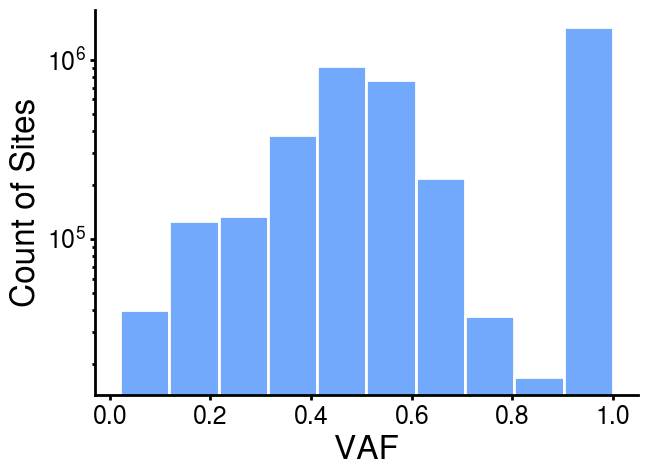

In [17]:
# sns.set_theme(style="ticks")
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(adata_bulk.var, x='bulk_vaf', 
             alpha=0.75,
             color = pal[2],
             linewidth=2,
             ax=ax,
             # log_scale=True,
             bins=10,
             edgecolor='white'
            )
ax.set_yscale('log')
ax.tick_params(labelsize=18)
plt.xlabel("VAF", fontsize=24)
plt.ylabel("Count of Sites", fontsize=24)

### Bulk/ Germline mutation spectrum

In [18]:
spc.tl.compute_spectrum(adata_bulk)

Computing spectrum (key='spectrum'): 100%|██████████| 1/1 [00:03<00:00,  3.05s/cell]


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
bulkHSC4,47501,31701,16919,24649,28861,24378,15618,24673,26395,18928,...,17448,17672,16135,15565,22799,27745,22965,23511,27281,47619


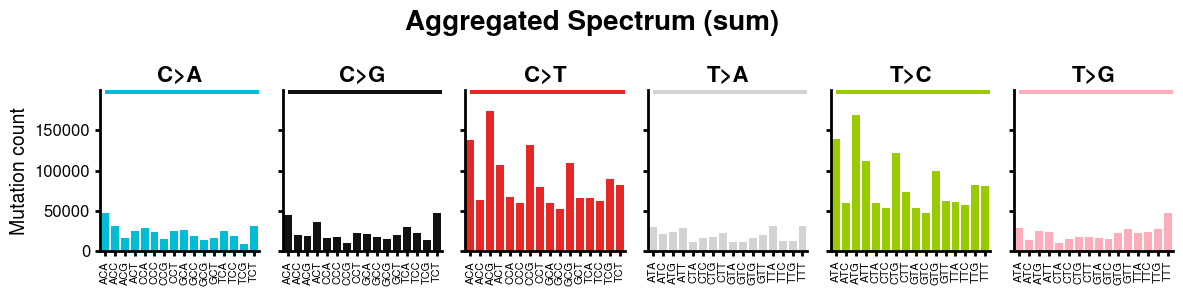

In [19]:
spc.pl.spectrum(adata_bulk, figsize=(12,3))

### Load single cells

In [20]:
HSC4_fpr = pd.read_csv('../data/benchmarking/fpr/HSC4_per_cell_fpr.tsv', index_col='sample', sep='\t')
HSC4_fpr.iloc[:10]

,donor,n_calls_total,n_snv_calls,n_indel_calls,n_evaluable,n_TP,n_FP,n_TP_singleton,n_lowcov,fp_fraction
sample,,,,,,,,,,
AAGGCTTGAGGAAGGCTAACACTCAGACACCAAAGGGTGACTCTA,HSC4,1345759,1109176,236583,1101723,834922,266801,4811,7453,0.242167
AAGGCTTGAGGACGACAAGAACTCTCCAGTCTAAGGCATACCGTA,HSC4,416425,347949,68476,341504,279809,61695,1604,6445,0.180657
AAGGCTTGAGGACGCTACTAACTCGGAACTGTAAGGACATCGTCA,HSC4,241056,202854,38202,199287,144749,54538,1341,3567,0.273666
AAGGCTTGAGGATACAGCAGACTCTGTTGGACAAGGTGGTCTCAA,HSC4,415069,347241,67828,340675,274014,66661,1704,6566,0.195673
ACCTCGTAAGGAAACTGCTCACTCGCAATGACAAGGCATACCGTA,HSC4,457508,380567,76941,373923,306636,67287,1759,6644,0.179949
ACTAACCGAGGATACAGCAGACTCAGGTCGTAAAGGTGGTCTCAA,HSC4,1569726,1293932,275794,1270567,1024128,246439,6299,23365,0.193960
ACTAACCGAGGATTCGGTAGACTCAGACGAACAAGGGTGACTCTA,HSC4,835691,696877,138814,692384,523279,169105,2941,4493,0.244236
AGGTCCAAAGGACTTCAGCAACTCGGAACTGTAAGGTGGTCTCAA,HSC4,467437,390935,76502,383808,310332,73476,1941,7127,0.191439
AGGTCCAAAGGAGTCTGCTAACTCTCTGCTTGAAGGTTGGATGCA,HSC4,284059,234975,49084,230872,183811,47061,1297,4103,0.203840


In [21]:
adata_sc = spc.pp.load_vcf('../data/benchmarking/joint/HSC4/HSC4_joint.vcf.gz')
adata_sc

Loading VCF: 11441403 sites [12:34, 15155.83 sites/s]


Building matrices for 11441403 sites × 50 samples...
Done! Loaded 11441403 sites × 50 samples


AnnData object with n_obs × n_vars = 50 × 11441403
    var: 'chrom', 'pos'
    uns: 'vcf_source', 'n_variants', 'n_cells'
    layers: 'DP', 'AD'

In [22]:
adata_sc.obs = annotate_barcodes(
    adata_sc.obs,
    bcs,
    column_name="amplification_method",
    conditions={"mMDA": [1], "PTA": [2], "Cell Growth": [3]},
)

adata_sc.obs = annotate_barcodes(
    adata_sc.obs,
    bcs,
    column_name="fragmentation",
    conditions={
        "A-tailing": ["A", "B", "C", "D"],
        "Fragmentase": ["E", "F", "G", "H"],
    },
)
# adata.obs

In [23]:
adata_sc.obs["condition"] = (
    adata_sc.obs["amplification_method"] + " + " + adata_sc.obs["fragmentation"]
)

In [24]:
## Filter out non snps
spc.pp.filter_to_snps(adata_sc, inplace=True)


In [25]:
spc.pp.annotate_contexts(adata_sc, fasta_path='/shared/biodata/reference/GATK/hg38/Homo_sapiens_assembly38.fasta')
adata_sc.var

Annotating trinuc contexts: 100%|██████████| 8815208/8815208 [01:25<00:00, 103229.33 sites/s]


,chrom,pos,anc,der,trinuc_type
chr1-10120-T>A,chr1,10120,CTA,CAA,CTA>CAA
chr1-10327-T>C,chr1,10327,CTA,CCA,CTA>CCA
chr1-10340-T>C,chr1,10340,CTA,CCA,CTA>CCA
chr1-10346-T>C,chr1,10346,CTA,CCA,CTA>CCA
chr1-14011-C>T,chr1,14011,ACA,ATA,ACA>ATA
...,...,...,...,...,...
chrY-56886944-C>T,chrY,56886944,ACG,ATG,ACG>ATG
chrY-56886952-T>C,chrY,56886952,CTA,CCA,CTA>CCA
chrY-56886963-A>T,chrY,56886963,TAT,TTT,ATA>AAA
chrY-56886992-T>C,chrY,56886992,TTA,TCA,TTA>TCA


In [26]:
bulk_variants = set(adata_bulk.var.loc[(adata_bulk.layers['AD']>0).toarray()[0]].index)

In [27]:
def FP(row):
    cell = row.name
    calls = set(adata_sc.var.loc[(adata_sc[cell,:].layers['AD']>1).toarray()[0]].index)
    TP = set(adata_sc.var.loc[(adata_sc[cell,:].layers['AD']>1).toarray()[0]].index).intersection(bulk_variants)
    TP_count = len(TP)
    FP_count = len(calls) - TP_count
    FP_prop = FP_count / len(calls)

    return FP_prop

adata_sc.obs['FP_rate'] = adata_sc.obs.apply(FP, axis=1)
# adata_sc.obs

In [28]:
def FP_sing(row):
    cell = row.name
    calls = set(adata_sc.var.loc[(adata_sc[cell,:].layers['AD']>0).toarray()[0]].index)
    TP = set(adata_sc.var.loc[(adata_sc[cell,:].layers['AD']>0).toarray()[0]].index).intersection(bulk_variants)
    TP_count = len(TP)
    FP_count = len(calls) - TP_count
    FP_prop = FP_count / len(calls)

    return FP_prop

adata_sc.obs['FP_rate_singletons'] = adata_sc.obs.apply(FP_sing, axis=1)
# adata_sc.obs

Text(0, 0.5, 'False Discovery Rate')

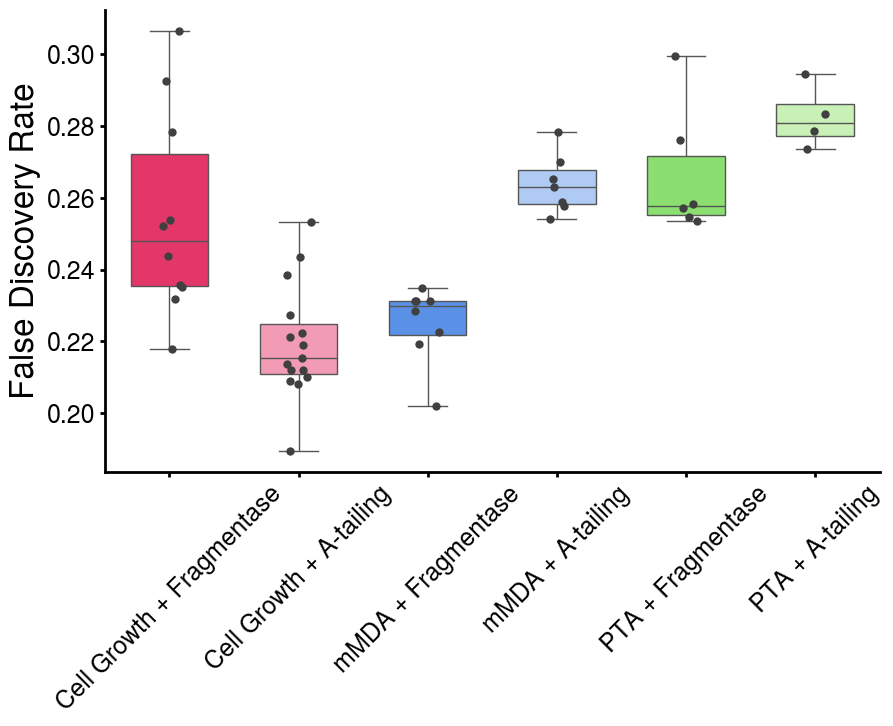

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.boxplot(
    data=adata_sc.obs,
    x="condition",
    y="FP_rate",
    order=[
        "Cell Growth + Fragmentase",
        "Cell Growth + A-tailing",
        "mMDA + Fragmentase",
        "mMDA + A-tailing",
        "PTA + Fragmentase",
        "PTA + A-tailing",
    ],
    ax=ax,
    hue="condition",
    palette=cond_pal,
    whis=(0, 100),
    width=0.6,
)

sns.stripplot(
    data=adata_sc.obs,
    x="condition",
    y="FP_rate",
    order=[
        "Cell Growth + Fragmentase",
        "Cell Growth + A-tailing",
        "mMDA + Fragmentase",
        "mMDA + A-tailing",
        "PTA + Fragmentase",
        "PTA + A-tailing",
    ],
    ax=ax,
    size=6,
    color=".25",
)

sns.despine()
plt.xlabel("")
plt.xticks(rotation=45)
ax.tick_params(labelsize=18)
# plt.ylim(0.175,0.4)
plt.ylabel("False Discovery Rate", fontsize=24)

In [30]:
import matplotlib as mpl
mpl.rcParams.update(
    {
        # Font
        "font.family": "sans-serif",
        "font.sans-serif": ["TeX Gyre Heros"],
        "font.size": 16,
        # Axes lines
        "axes.linewidth": 2,
        # Tick marks
        "xtick.major.width": 2,
        "ytick.major.width": 2,
        "xtick.minor.width": 2,
        "ytick.minor.width": 2,
        # Tick direction (outward is common in publications)
        "xtick.direction": "out",
        "ytick.direction": "out",
    }
)

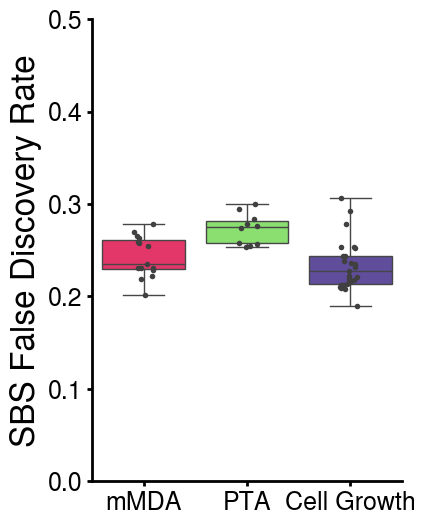

In [31]:
# sns.set_theme(style="ticks", palette="pastel")
fig, ax = plt.subplots(1, 1, figsize=(4, 6))
sns.boxplot(
    data=adata_sc.obs,
    x="amplification_method",
    y="FP_rate",
    order=['mMDA', 'PTA', 'Cell Growth'],
    ax=ax,
    hue="amplification_method",
    palette=pub_pal,
    whis=(0, 100),
    width=0.8,
)

sns.stripplot(
    data=adata_sc.obs,
    x="amplification_method",
    y="FP_rate",
    order=['mMDA', 'PTA', 'Cell Growth'],
    ax=ax,
    size=4,
    color=".25",
)

sns.despine()
# plt.xlabel("Amplification Method", fontsize=24)

plt.xlabel("")
# plt.xticks(rotation=45)
ax.tick_params(labelsize=18)
plt.ylim(0,0.5)
plt.ylabel("SBS False Discovery Rate", fontsize=24)

fig.savefig('../results/benchmarking/HSC_fpr.png', bbox_inches='tight', dpi=600)

### Public data

In [32]:
BJ_fibroblast = pd.read_csv('../data/benchmarking/fpr/BJ_fibroblast_per_cell_fpr.tsv', index_col='sample', sep='\t')
CD34_cord_blood = pd.read_csv('../data/benchmarking/fpr/CD34_cord_blood_per_cell_fpr.tsv', index_col='sample', sep='\t')
pub_fpr = pd.concat([BJ_fibroblast,CD34_cord_blood])
pub_fpr.drop(['SRR5365365', 'SRR5365366', 'SRR5365367'], inplace=True)
pub_fpr

,donor,n_calls_total,n_snv_calls,n_indel_calls,n_evaluable,n_TP,n_FP,n_TP_singleton,n_lowcov,fp_fraction
sample,,,,,,,,,,
SRR5365331,BJ_fibroblast,2236653,1639098,597555,1596192,1416787,179405,4250,42906,0.112396
SRR5365333,BJ_fibroblast,2097209,1538879,558330,1495822,1287688,208134,4575,43057,0.139144
SRR5365335,BJ_fibroblast,2237127,1625006,612121,1582405,1409382,173023,4240,42601,0.109342
SRR5365336,BJ_fibroblast,2140850,1544454,596396,1498279,1296023,202256,4828,46175,0.134992
SRR5365337,BJ_fibroblast,2153541,1560202,593339,1516972,1348256,168716,3991,43230,0.111219
...,...,...,...,...,...,...,...,...,...,...
SRR8438293,CD34_cord_blood,2274957,1877951,397006,1827895,1796012,31883,1820,50056,0.017442
SRR8438294,CD34_cord_blood,2268876,1867262,401614,1807881,1779132,28749,1900,59381,0.015902
SRR8438295,CD34_cord_blood,2164238,1768426,395812,1706302,1681072,25230,1918,62124,0.014786


In [33]:
PTA_meta = pd.read_csv(
    "../results/benchmarking/PTA_meta.tsv", sep="\t", index_col="SRA_Run"
)


def rename(row):
    if row.amplification_method == "SCMDA":
        return "MDA"
    elif row.amplification_method == "PTA":
        return "PTA"
    elif pd.isna(row.amplification_method) or row.amplification_method == "":
        return "PTA"  # blank = PTA (confirmed from SRA metadata)
    else:
        return None  # 'None' and anything unexpected → drop


PTA_meta["amplification_method"] = PTA_meta.apply(rename, axis=1)
PTA_meta["study"] = "Gonzalez-Pena"
PTA_meta = PTA_meta[["study", "amplification_method"]]
PTA_meta = PTA_meta.dropna()
# PTA_meta

In [34]:
LIANTI_meta_1 = pd.read_csv(
    "../results/benchmarking/LIANTI_meta.tsv", sep="\t", index_col="SRA_Run"
)
LIANTI_meta_2 = pd.read_csv(
    "../results/benchmarking/LIANTI_meta_additional.tsv", sep="\t", index_col="SRA_Run"
)
LIANTI_meta = pd.concat([LIANTI_meta_1, LIANTI_meta_2])
LIANTI_meta["study"] = "Chen"


def amp(row):
    if "LIANTI" in row.replicate:
        return "LIANTI"
    elif "MDA" in row.replicate:
        return "MDA"
    elif "MALBAC" in row.replicate:
        return "MALBAC"
    elif "DOP-PCR" in row.replicate:
        return "DOP-PCR"
    elif "Bulk" in row.replicate:
        return "Bulk"
    else:
        return "LIANTI"


LIANTI_meta["amplification_method"] = LIANTI_meta.apply(amp, axis=1)
LIANTI_meta = LIANTI_meta[
    LIANTI_meta["amplification_method"].isin(["LIANTI", "MDA", "MALBAC", "Bulk"])
]
LIANTI_meta = LIANTI_meta[["study", "amplification_method"]]
# LIANTI_meta

In [35]:
combined_meta = pd.concat([PTA_meta, LIANTI_meta])
combined_meta = combined_meta.drop(["SRR8438299"])
# combined_meta = combined_meta.drop(["SRR8438299"])

In [36]:
HSC4_fpr['study'] = 'Mullaney et al.'
HSC4_fpr['amplification_method'] = 'CapWGS'
# HSC4_fpr

In [37]:
pub_fpr = pd.concat([combined_meta.loc[pub_fpr.index], pub_fpr], axis=1)
pub_fpr = pub_fpr[HSC4_fpr.columns]
combined_fpr = pd.concat([pub_fpr, HSC4_fpr])

combined_fpr

,donor,n_calls_total,n_snv_calls,n_indel_calls,n_evaluable,n_TP,n_FP,n_TP_singleton,n_lowcov,fp_fraction,study,amplification_method
sample,,,,,,,,,,,,
SRR5365331,BJ_fibroblast,2236653,1639098,597555,1596192,1416787,179405,4250,42906,0.112396,Chen,LIANTI
SRR5365333,BJ_fibroblast,2097209,1538879,558330,1495822,1287688,208134,4575,43057,0.139144,Chen,LIANTI
SRR5365335,BJ_fibroblast,2237127,1625006,612121,1582405,1409382,173023,4240,42601,0.109342,Chen,LIANTI
SRR5365336,BJ_fibroblast,2140850,1544454,596396,1498279,1296023,202256,4828,46175,0.134992,Chen,LIANTI
SRR5365337,BJ_fibroblast,2153541,1560202,593339,1516972,1348256,168716,3991,43230,0.111219,Chen,LIANTI
...,...,...,...,...,...,...,...,...,...,...,...,...
TATCAGCCAGGATTGGTAGCACTCGTGTGATGAAGGTGACAGTGA,HSC4,625557,509303,116254,506405,398846,107559,1767,2898,0.212397,Mullaney et al.,CapWGS
TATCCGGTAGGACCATACGAACTCAGGTCGTAAAGGGTCCGATTA,HSC4,841569,676841,164728,672182,501360,170822,2564,4659,0.254131,Mullaney et al.,CapWGS
TGTGGTTGAGGAAGGCATTGACTCGTGTGATGAAGGTTCCACTCA,HSC4,1046182,869162,177020,854165,690746,163419,4168,14997,0.191320,Mullaney et al.,CapWGS


In [38]:
combined_fpr.amplification_method.unique()

array(['LIANTI', 'MALBAC', 'MDA', 'PTA', 'CapWGS'], dtype=object)

Text(0, 0.5, 'False Discovery Rate')

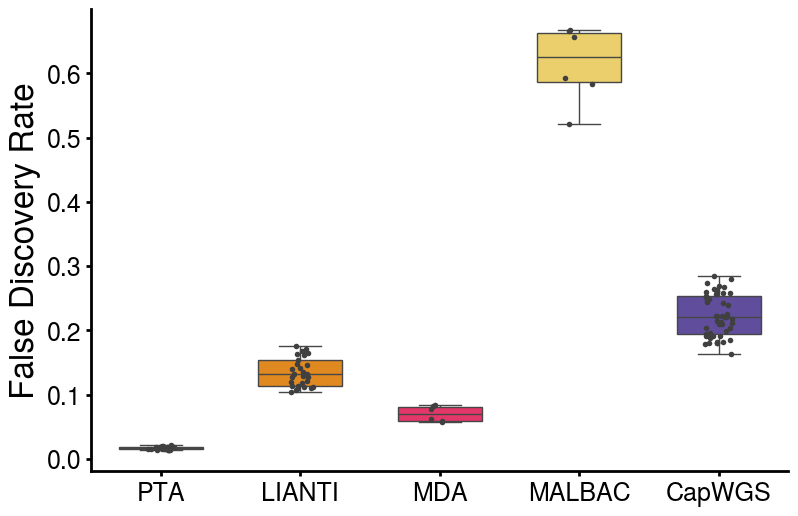

In [39]:
# sns.set_theme(style="ticks", palette="pastel")
fig, ax = plt.subplots(1, 1, figsize=(9, 6))
sns.boxplot(
    data=combined_fpr,
    x="amplification_method",
    y="fp_fraction",
    order=['PTA', 'LIANTI', 'MDA', 'MALBAC', 'CapWGS'],
    ax=ax,
    hue="amplification_method",
    palette=pub_pal,
    whis=(0, 100),
    width=0.6,
)

sns.stripplot(
    data=combined_fpr,
    x="amplification_method",
    y="fp_fraction",
    order=['PTA', 'LIANTI', 'MDA', 'MALBAC', 'CapWGS'],
    ax=ax,
    size=4,
    color=".25",
)

sns.despine()
plt.xlabel("", fontsize=24)
# plt.xticks(rotation=45)
ax.tick_params(labelsize=18)
# plt.ylim(0.175,0.4)
plt.ylabel("False Discovery Rate", fontsize=24)

# fig.savefig('../results/benchmarking/HSC_gini_2.png', bbox_inches='tight', dpi=600)

Text(0, 0.5, 'False Discovery Rate')

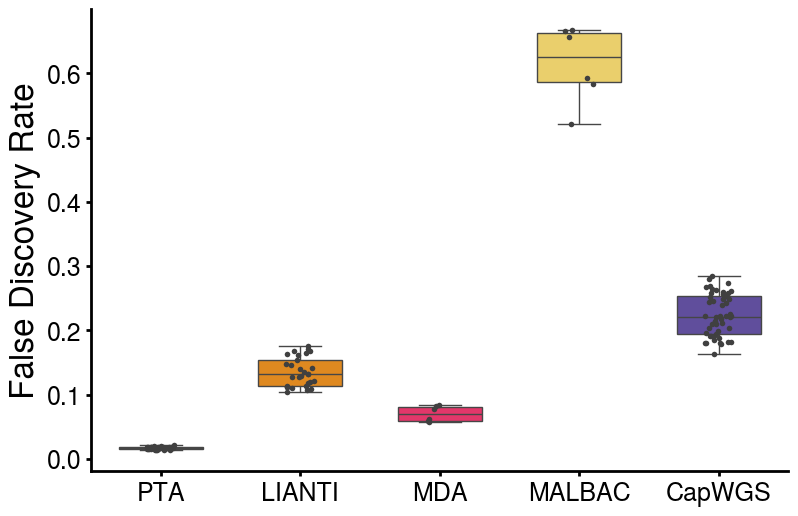

In [40]:
# sns.set_theme(style="ticks", palette="pastel")
fig, ax = plt.subplots(1, 1, figsize=(9, 6))
sns.boxplot(
    data=combined_fpr,
    x="amplification_method",
    y="fp_fraction",
    order=['PTA', 'LIANTI', 'MDA', 'MALBAC', 'CapWGS'],
    ax=ax,
    hue="amplification_method",
    palette=pub_pal,
    whis=(0, 100),
    width=0.6,
)

sns.stripplot(
    data=combined_fpr,
    x="amplification_method",
    y="fp_fraction",
    order=['PTA', 'LIANTI', 'MDA', 'MALBAC', 'CapWGS'],
    ax=ax,
    size=4,
    color=".25",
)

sns.despine()
plt.xlabel("", fontsize=24)
# plt.xticks(rotation=45)
ax.tick_params(labelsize=18)
# plt.ylim(0.175,0.4)
plt.ylabel("False Discovery Rate", fontsize=24)

# fig.savefig('../results/benchmarking/HSC_gini_2.png', bbox_inches='tight', dpi=600)

In [41]:
combined_fpr.to_csv('../results/benchmarking/SBS_fdr_pub.csv')

In [42]:
adata_sc.obs.to_csv('../results/benchmarking/SBS_fdr_capwgs.csv')

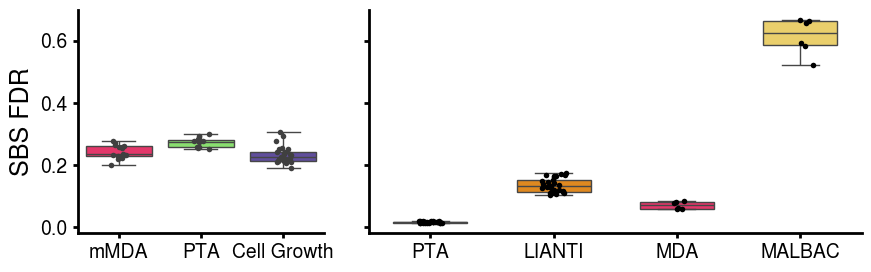

SBS FDR per method (all):
                       mean    std  median  count
amplification_method                             
CapWGS                0.224  0.032   0.221     50
LIANTI                0.135  0.023   0.132     29
MALBAC                0.615  0.059   0.625      6
MDA                   0.070  0.012   0.070      6
PTA                   0.017  0.002   0.017     29

CapWGS sub-methods:
                       mean    std  median  count
amplification_method                             
Cell Growth           0.234  0.028   0.227     25
PTA                   0.273  0.017   0.275     10
mMDA                  0.243  0.022   0.235     15


In [43]:
# SBS FDR — side-by-side panels (CapWGS sub-methods, all methods), shared y
order_cap = ['mMDA', 'PTA', 'Cell Growth']
order_pub = ['PTA', 'LIANTI', 'MDA', 'MALBAC']

fig, axes = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw={"width_ratios":[1, 2]}, sharey=True)

ax = axes[0]
sns.boxplot(data=adata_sc.obs, x="amplification_method", y="FP_rate", order=order_cap,
            ax=ax, hue="amplification_method", palette=pub_pal, whis=(0,100), width=0.8, legend=False)
sns.stripplot(data=adata_sc.obs, x="amplification_method", y="FP_rate", order=order_cap,
              ax=ax, size=4, color=".25")
ax.set_xlabel(""); ax.set_ylabel("SBS FDR", fontsize=18)
ax.tick_params(labelsize=14); sns.despine(ax=ax)
for spine in ax.spines.values():
    spine.set_color('black')
ax = axes[1]
sns.boxplot(data=combined_fpr[combined_fpr['amplification_method']!='CapWGS'], x="amplification_method", y="fp_fraction", order=order_pub,
            ax=ax, hue="amplification_method", palette=pub_pal, whis=(0,100), width=0.6, legend=False)
sns.stripplot(data=combined_fpr[combined_fpr['amplification_method']!='CapWGS'], x="amplification_method", y="fp_fraction", order=order_pub,
              ax=ax, size=4, color="black")
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=14); ax.tick_params(axis="y", labelsize=14)
sns.despine(ax=ax)
for spine in ax.spines.values():
    spine.set_color('black')
plt.tight_layout()
fig.savefig('../results/benchmarking/sbs_fdr.png', bbox_inches='tight', dpi=600)
plt.show()

print("SBS FDR per method (all):")
print(combined_fpr.groupby("amplification_method")["fp_fraction"].agg(["mean","std","median","count"]).round(3).to_string())
print()
print("CapWGS sub-methods:")
print(adata_sc.obs.groupby("amplification_method")["FP_rate"].agg(["mean","std","median","count"]).round(3).to_string())

# FP mutation spectrum

In [44]:
FPs = set()
for cell in list(adata_sc.obs.index):
    calls = set(adata_sc.var.loc[(adata_sc[cell,:].layers['AD']>1).toarray()[0]].index)
    TP = set(adata_sc.var.loc[(adata_sc[cell,:].layers['AD']>1).toarray()[0]].index).intersection(bulk_variants)
    FP = calls - TP
    FPs.update(FP)
    
adata_sc.var.loc[np.array(FPs)]

,chrom,pos,anc,der,trinuc_type
chr10-51139780-A>G,chr10,51139780,GAG,GGG,CTC>CCC
chr18-77735980-T>C,chr18,77735980,CTT,CCT,CTT>CCT
chr10-63312917-C>T,chr10,63312917,GCA,GTA,GCA>GTA
chr1-85899329-A>T,chr1,85899329,TAA,TTA,TTA>TAA
chr17-18353349-A>G,chr17,18353349,CAG,CGG,CTG>CCG
...,...,...,...,...,...
chrX-25354755-C>A,chrX,25354755,GCA,GAA,GCA>GAA
chr10-131796402-A>T,chr10,131796402,CAT,CTT,ATG>AAG
chr2-228925884-G>A,chr2,228925884,GGT,GAT,ACC>ATC
chr1-124375527-A>C,chr1,124375527,AAA,ACA,TTT>TGT


In [45]:
def FP(row):
    if row.name in FPs:
        return True
    else:
        return False

adata_sc.var['FP'] = adata_sc.var.apply(FP, axis=1)
adata_sc.var

,chrom,pos,anc,der,trinuc_type,FP
chr1-10120-T>A,chr1,10120,CTA,CAA,CTA>CAA,True
chr1-10327-T>C,chr1,10327,CTA,CCA,CTA>CCA,True
chr1-10340-T>C,chr1,10340,CTA,CCA,CTA>CCA,True
chr1-10346-T>C,chr1,10346,CTA,CCA,CTA>CCA,True
chr1-14011-C>T,chr1,14011,ACA,ATA,ACA>ATA,True
...,...,...,...,...,...,...
chrY-56886944-C>T,chrY,56886944,ACG,ATG,ACG>ATG,False
chrY-56886952-T>C,chrY,56886952,CTA,CCA,CTA>CCA,False
chrY-56886963-A>T,chrY,56886963,TAT,TTT,ATA>AAA,False
chrY-56886992-T>C,chrY,56886992,TTA,TCA,TTA>TCA,False


In [46]:
FP_spectrum = spc.tl.compute_spectrum_from_mask(adata_sc, "FP")

In [47]:
spc.pl.spectrum_from_df(FP_spectrum, figsize = (12, 3), outpath='../results/benchmarking/FP_spectrum.png')

Saved: ../results/benchmarking/FP_spectrum.png


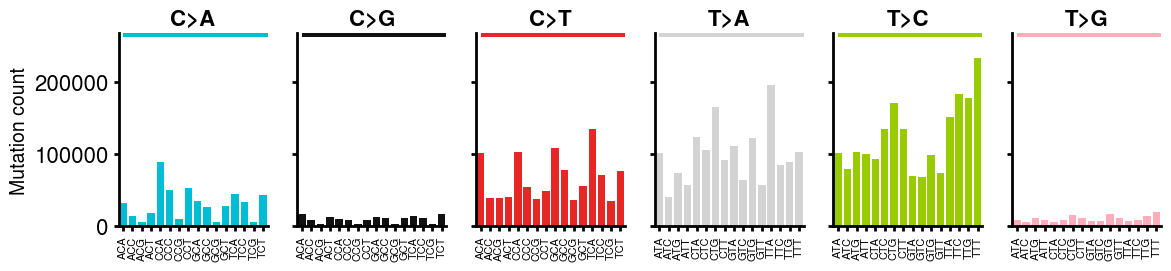

In [48]:
spc.pl.spectrum_from_df(FP_spectrum, figsize = (12, 3))

In [50]:
FP_spectrum.to_csv('../results/benchmarking/FP_spectrum.csv')

In [51]:
FP_spectrum = pd.read_csv('../results/benchmarking/FP_spectrum.csv', index_col=0)['0']
FP_spectrum
# FP_spectrum.values[None, :].shape

ACA>AAA    32749
ACC>AAC    13829
ACG>AAG     5151
ACT>AAT    18975
CCA>CAA    89802
           ...  
GTT>GGT    11843
TTA>TGA     7850
TTC>TGC     8439
TTG>TGG    14458
TTT>TGT    19024
Name: 0, Length: 96, dtype: int64

In [52]:
spc.tl.fit_cosmic_signatures(spectrum=FP_spectrum, output_dir='../results/benchmarking/sigprofiler_FP')


Fitting COSMIC v3.4 signatures to spectrum 'spectrum'...
SigProfiler outputs will be saved to: ../results/benchmarking/sigprofiler_FP
Converted spectrum to SigProfiler format: ../results/benchmarking/sigprofiler_FP/input/matrix.txt
Analyzing 1 samples with 5449794 total mutations
Running SigProfilerAssignment (this may take a few minutes)...
Assigning COSMIC sigs or Signature Database ...... 





                                        ################ Sample 1 #################
############################# Initial Composition #################################### 
   SBS1      SBS2      SBS3  SBS4  SBS5     SBS6    SBS7a  SBS7b    SBS7c  \
0   0.0  119371.0  144994.0   0.0   0.0  38084.0  32914.0    0.0  92064.0   

   SBS7d  ...     SBS90   SBS91  SBS92  SBS93  SBS94     SBS95  SBS96  \
0    0.0  ...  160879.0  1946.0    0.0    0.0    0.0  232529.0    0.0   

     SBS97  SBS98  SBS99  
0  78448.0    0.0    0.0  

[1 rows x 86 columns]
L2%:  0.2507129975616669
#######################

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.2s finished




 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
Parsing results...


ValueError: Activities file contains unexpected sample names: [0]. Expected: ['0']